# Red Neuronal desde código modular (src/train.py)


In [1]:
# Importar librerias
import sys
import os
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

In [2]:
# Ajustar ruta para importar desde src/
sys.path.append("../src")
import train

In [3]:
# Cargar configuración y datos
config = train.load_config()
X, y = train.load_data()
X_train, X_test, y_train, y_test = train.preprocess(X, y, config)

## Entrenamiento de la Red Neuronal (Keras)

Se entrenó una red densa definida en `src/train.py` durante 20 épocas con optimizador Adam y pérdida binaria. A continuación se resumen los principales resultados observados en el log de entrenamiento:

- Exactitud en entrenamiento: estable en torno a 0.887–0.888 desde las primeras épocas.
- Exactitud en validación: estable en torno a 0.888–0.889 durante todo el entrenamiento.
- Pérdida en entrenamiento: desciende de ~0.44 a ~0.333.
- Pérdida en validación: desciende inicialmente (≈0.392 → ≈0.351–0.354) y luego se mantiene prácticamente plana.

### Interpretación
- No se observa mejora sustantiva en exactitud de validación tras las primeras épocas; el modelo alcanza rápidamente su meseta.
- La pérdida de validación desciende al inicio y luego oscila alrededor de ~0.351–0.354, lo que sugiere estancamiento y un posible inicio de sobreajuste leve si se extendieran más épocas.
- La exactitud cercana a 0.888 es coherente con el fuerte desbalance de clases del problema y no refleja necesariamente una buena detección de la clase positiva. Será necesario evaluar con métricas sensibles al desbalance (ROC AUC, matriz de confusión, precisión/recobrado por clase y, de ser posible, PR AUC).




In [4]:
# Construir y entrenar el modelo
model = train.build_model(config, input_dim=X.shape[1])
history = train.train_model(model, X_train, y_train, config)

c:\USS\Repositorios Github\Deep Learning\DeepNeuralNetworkUSS-1\Projects\HospitalReadmission\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8817 - loss: 0.4410 - val_accuracy: 0.8885 - val_loss: 0.3920
Epoch 2/20
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8874 - loss: 0.3713 - val_accuracy: 0.8888 - val_loss: 0.3659
Epoch 3/20
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8878 - loss: 0.3570 - val_accuracy: 0.8891 - val_loss: 0.3583
Epoch 4/20
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8880 - loss: 0.3506 - val_accuracy: 0.8888 - val_loss: 0.3614
Epoch 5/20
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8878 - loss: 0.3469 - val_accuracy: 0.8888 - val_loss: 0.3558
Epoch 6/20
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8879 - loss: 0.3436 - val_accuracy: 0.8889 - val_loss: 0.3556
Epoch 7/20
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8879 - loss: 0.3418 - val_accuracy: 0.8887 - val_loss: 0.3548
Epoch 8/20
1990/1990 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8881 - loss: 0.3400 -

## Evaluación del Modelo de Red Neuronal

Tras entrenar la red neuronal, se evaluó su desempeño sobre el conjunto de prueba.  
Los principales resultados fueron los siguientes:

- **Exactitud global (accuracy):** 0.89, valor elevado pero influenciado por el desbalance de clases.
- **Clase 0 (no readmitido):**
  - Precisión: 0.89  
  - Recall: 1.00  
  - F1-Score: 0.94  
  El modelo clasifica con gran exactitud a los pacientes no readmitidos.
- **Clase 1 (readmitido):**
  - Precisión: 0.33  
  - Recall: 0.01  
  - F1-Score: 0.01  
  El modelo prácticamente no logra identificar correctamente a los pacientes readmitidos.
- **ROC AUC:** 0.625, indicando baja capacidad de discriminación entre ambas clases.

### Interpretación
- La exactitud general es alta, pero está sesgada debido a la fuerte predominancia de la clase negativa (no readmitidos).  
- El modelo tiende a clasificar casi todos los casos como **no readmitidos**, lo que se refleja en el recall cercano a 0 en la clase positiva.  
- El ROC AUC de 0.625 confirma que la red neuronal apenas logra diferenciar entre ambas clases.

### Conclusión
Si bien la red neuronal reproduce el mismo comportamiento que el modelo de regresión logística, sigue fallando en la detección de la clase minoritaria.  
Esto sugiere que el desbalance de clases sigue siendo el principal desafío, por lo que deben aplicarse técnicas de balanceo (undersampling, oversampling o ajuste de `class_weight`) para mejorar la sensibilidad hacia la clase positiva.


In [5]:
# Evaluación
y_pred_proba = model.predict(X_test).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17665
           1       0.33      0.01      0.01      2234

    accuracy                           0.89     19899
   macro avg       0.61      0.50      0.48     19899
weighted avg       0.82      0.89      0.84     19899

ROC AUC: 0.6251438350419538


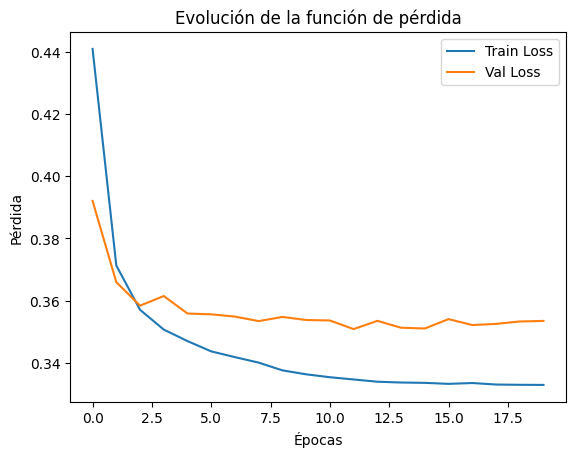

In [6]:
# Visualización de métricas
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Evolución de la función de pérdida")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
plt.show()

In [7]:
# Al final de RedNeuronal.ipynb
model.save("../models/modelo_nn.keras")

## Balanceo por Undersampling (Red Neuronal)

El conjunto de datos presenta un desbalance marcado entre clases, lo que favorece predicciones hacia “no readmitido”.  
Para mitigar este sesgo en el entrenamiento de la red neuronal, se reducirá la clase mayoritaria en el **conjunto de entrenamiento** hasta igualar el tamaño de la clase minoritaria (undersampling).  

Con esta estrategia se busca:
- Forzar al modelo a aprender patrones asociados a la clase minoritaria.
- Aumentar el recall en la detección de readmisión.
- Aceptar, como posible costo, una menor exactitud global por pérdida de información de la clase mayoritaria.

> Nota: el balanceo se aplica **solo** al set de entrenamiento. La evaluación se mantiene sobre el set de prueba original para medir la generalización en la distribución real.


## Resultados del Modelo con Undersampling (Red Neuronal)

Tras aplicar undersampling en el conjunto de entrenamiento, el modelo fue reentrenado y evaluado sobre el conjunto de prueba original.

**Métricas principales:**
- Accuracy: 54%  
- Recall (clase 1 – readmitidos): 0.55  
- Precision (clase 1 – readmitidos): 0.13  
- F1-score (clase 1): 0.21  
- ROC AUC: 0.56

**Interpretación:**
- El modelo pierde gran parte de la exactitud global en comparación con el baseline (que estaba en torno al 89%), debido a que ahora está forzado a "arriesgarse" más con la clase minoritaria.  
- El recall para los pacientes readmitidos mejora significativamente (de 0.02 en el baseline a 0.55 en este modelo). Esto implica que ahora logra identificar a más de la mitad de los pacientes que efectivamente fueron readmitidos.  
- Sin embargo, la precisión en la clase positiva cae a 0.13, lo que significa que de todos los pacientes que el modelo clasifica como readmitidos, la gran mayoría son falsos positivos.  
- El área bajo la curva ROC (0.56) refleja que el modelo sigue teniendo un desempeño apenas mejor que el azar en términos de discriminación global.

**Conclusión:**
El undersampling ayuda a visibilizar la clase minoritaria y a aumentar el recall de los pacientes readmitidos, aunque a costa de reducir drásticamente la precisión y la exactitud global. Este trade-off es esperado en escenarios de balanceo y debe evaluarse según el objetivo del problema (por ejemplo, priorizar identificar a pacientes en riesgo de readmisión aunque conlleve más falsos positivos).


Distribución original (y_train):
readmitted
0    0.887743
1    0.112257
Name: proportion, dtype: float64

Distribución balanceada (y_train_bal):
0    0.5
1    0.5
Name: proportion, dtype: float64


c:\USS\Repositorios Github\Deep Learning\DeepNeuralNetworkUSS-1\Projects\HospitalReadmission\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5624 - loss: 0.7623 - val_accuracy: 0.5669 - val_loss: 0.7485
Epoch 2/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6467 - loss: 0.6841 - val_accuracy: 0.5786 - val_loss: 0.7683
Epoch 3/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6812 - loss: 0.6499 - val_accuracy: 0.5730 - val_loss: 0.7880
Epoch 4/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7012 - loss: 0.6291 - val_accuracy: 0.5733 - val_loss: 0.8378
Epoch 5/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7287 - loss: 0.6052 - val_accuracy: 0.5727 - val_loss: 0.8620
Epoch 6/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7563 - loss: 0.5798 - val_accuracy: 0.5579 - val_loss: 0.9187
Epoch 7/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7783 - loss: 0.5537 - val_accuracy: 0.5562 - val_loss: 0.9640
Epoch 8/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8041 - loss: 0.5265 - val_accuracy: 0.

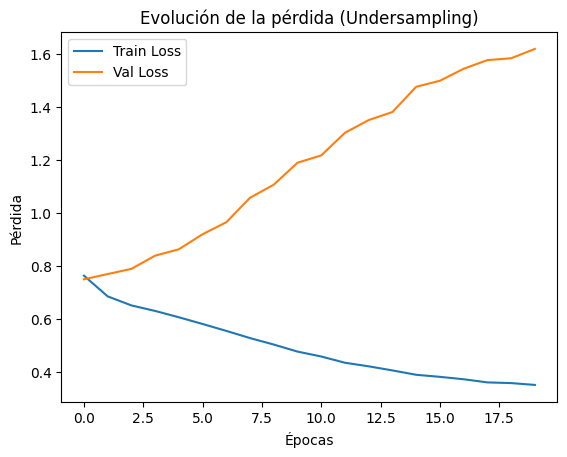

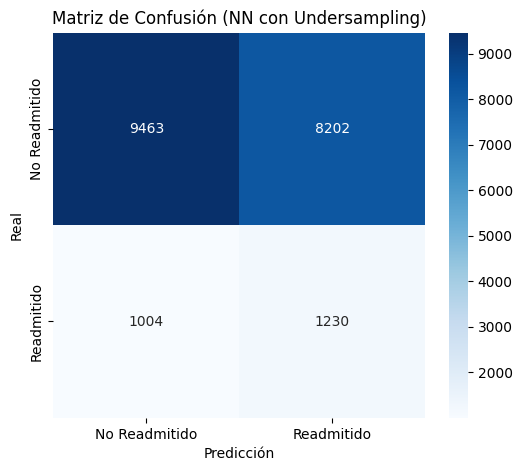

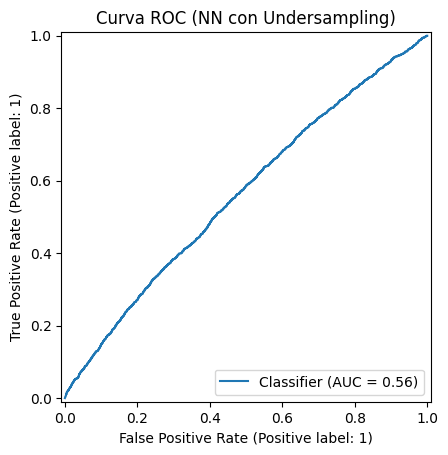


Modelo guardado en ../models/modelo_nn_undersampling.keras


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1) UNDERSAMPLING en el set de entrenamiento (manteniendo test intacto)
# Unimos X_train e y_train para muestrear por clase
train_df = pd.DataFrame(X_train)
train_df['readmitted'] = y_train.values if hasattr(y_train, 'values') else y_train

# Separar por clases
maj = train_df[train_df['readmitted'] == 0]
minr = train_df[train_df['readmitted'] == 1]

# Submuestrear la clase mayoritaria al tamaño de la minoritaria
maj_down = maj.sample(n=len(minr), random_state=42, replace=False)

# Combinar y barajar
balanced = pd.concat([maj_down, minr], axis=0).sample(frac=1.0, random_state=42)

# Volver a X/y (como arrays, que es lo que espera Keras)
X_train_bal = balanced.drop(columns=['readmitted']).to_numpy()
y_train_bal = balanced['readmitted'].to_numpy()

print("Distribución original (y_train):")
print(pd.Series(y_train).value_counts(normalize=True).rename('proportion'))
print("\nDistribución balanceada (y_train_bal):")
print(pd.Series(y_train_bal).value_counts(normalize=True).rename('proportion'))

# 2) Construir y entrenar modelo NUEVO (para no sobrescribir el anterior)
model_under = train.build_model(config, input_dim=X.shape[1])

history_under = train.train_model(
    model_under, 
    X_train_bal, y_train_bal, 
    config
)

# 3) Evaluación en el set de prueba ORIGINAL
y_proba_under = model_under.predict(X_test).flatten()
y_pred_under  = (y_proba_under > 0.5).astype(int)

print("\n== Reporte de Clasificación (Undersampling) ==")
print(classification_report(y_test, y_pred_under))
print("ROC AUC (Undersampling):", roc_auc_score(y_test, y_proba_under))

# 4) Curvas y matrices
# Pérdida (loss) durante el entrenamiento
plt.figure()
plt.plot(history_under.history["loss"], label="Train Loss")
plt.plot(history_under.history["val_loss"], label="Val Loss")
plt.title("Evolución de la pérdida (Undersampling)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
plt.show()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_under)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Readmitido", "Readmitido"],
            yticklabels=["No Readmitido", "Readmitido"])
plt.title("Matriz de Confusión (NN con Undersampling)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba_under)
plt.title("Curva ROC (NN con Undersampling)")
plt.show()

# 5) Guardar modelo balanceado aparte (no sobrescribir el anterior)
model_under.save("../models/modelo_nn_undersampling.keras")
print("\nModelo guardado en ../models/modelo_nn_undersampling.keras")


## Comparación de Modelos

Se entrenaron y evaluaron tres enfoques distintos sobre el problema de readmisión hospitalaria:

1. **Regresión Logística (Dataset Original)**
   - Accuracy: ~0.89  
   - Recall clase 1 (readmitidos): muy bajo (~0.02)  
   - ROC AUC: ~0.63  
   - Observación: el modelo aprende a predecir casi siempre la clase mayoritaria, ignorando la minoritaria.

2. **Regresión Logística con Undersampling**
   - Accuracy: ~0.62  
   - Recall clase 1: mejora considerablemente (~0.56)  
   - Precisión clase 1: baja (~0.16)  
   - ROC AUC: ~0.63  
   - Observación: el balance forzado mejora la detección de pacientes readmitidos, aunque sacrifica precisión y exactitud global.

3. **Red Neuronal con Undersampling**
   - Accuracy: ~0.54  
   - Recall clase 1: ~0.55  
   - Precisión clase 1: muy baja (~0.13)  
   - ROC AUC: ~0.56  
   - Observación: la red neuronal logra comportamiento similar a la regresión logística balanceada, sin mejoras claras en recall y con mayor inestabilidad en validación.

**Síntesis:**  
- El **modelo base** muestra alta exactitud pero falla en capturar casos positivos.  
- Con **undersampling**, tanto la regresión logística como la red neuronal aumentan el recall, aunque a costa de precisión.  
- Ninguno de los modelos alcanza un desempeño equilibrado entre precisión y sensibilidad, lo que refleja la complejidad del dataset y el impacto del desbalanceo.


## Conclusiones

- El conjunto de datos presenta un **fuerte desbalanceo** (89% de pacientes no readmitidos), lo que afecta directamente la capacidad de los modelos para identificar la clase minoritaria.
- El **modelo base (logístico)** confirmó el problema: alto accuracy global, pero recall casi nulo para los pacientes readmitidos.
- Con la técnica de **undersampling** se logró aumentar el recall, mostrando que el balanceo de clases es clave para este problema. Sin embargo, esto redujo la precisión y la exactitud global.
- La **red neuronal**, bajo la misma estrategia de undersampling, no superó a la regresión logística, lo que sugiere que la complejidad del modelo no garantiza mejoras cuando los datos están fuertemente desbalanceados.
- Para futuras iteraciones se recomienda:
  - Explorar técnicas de oversampling como **SMOTE**.  
  - Ajustar umbrales de decisión en lugar de usar el 0.5 por defecto.  
  - Probar modelos más robustos como **árboles de decisión o ensembles (Random Forest, XGBoost)** que suelen manejar mejor el desbalanceo.  

En síntesis, la tarea permitió observar el impacto del desbalanceo y comparar distintas estrategias de modelado, resaltando la importancia de evaluar métricas más allá del accuracy cuando se trabaja con datos de salud.
